# Notebook 16 — Fixed-Endpoint Pseudo-OCV Audit

## Goal

This notebook audits a fixed-endpoint voltage-recovery / pseudo-OCV diagnostic protocol for the SEI-only aging branch.

The goal is to test whether SEI-aged states show a measurable post-load voltage recovery signature when all checkpoints are driven to the same loaded terminal-voltage endpoint `Ukl`.

The diagnostic concept is:

fixed C-rate discharge  
→ same loaded terminal voltage endpoint `Ukl`  
→ current interruption  
→ fixed rest duration  
→ evaluate `U00_after_rest` and voltage recovery features

## Scientific context

Notebook 15 established Metric Registry v0.1 and classified SEI-only aging as:

`capacity / LLI dominant mixed signature`

with:

- strong degradation-state drift,
- clear but small external capacity fade,
- weak multi-window Ri drift,
- weak fitted and non-parametric relaxation drift.

Notebook 15 also registered voltage-recovery / pseudo-OCV features as feasibility-level metrics.

The present notebook turns that feasibility layer into a dedicated diagnostic protocol.

## Important terminology

The voltage after fixed rest is called:

- `U00_after_fixed_rest`
- `pseudo_OCV_after_rest`
- fixed-endpoint voltage-recovery descriptor

It is not a strict OCV-SOC measurement.

Reason:

The same loaded terminal voltage `Ukl` does not guarantee the same SOC or the same internal electrochemical state, especially after aging.

Therefore, this notebook interprets `U00_after_fixed_rest` as a voltage-recovery fingerprint, not as a true OCV-SOC point.

## Diagnostic protocol concept

At each SEI-only aging checkpoint:

1. Continue SEI-only aging to the checkpoint.
2. Branch into diagnostic full-charge preconditioning.
3. Discharge at a fixed C-rate until the same loaded terminal voltage `Ukl`.
4. Interrupt current.
5. Rest for a fixed duration.
6. Extract:
   - time to reach `Ukl`,
   - discharged capacity to `Ukl`,
   - voltage immediately after current interruption,
   - `U00_after_fixed_rest`,
   - recovery amplitude,
   - voltage recovery curve descriptors.

## Checkpoints

This notebook uses:

- 0 cycles
- 3 cycles
- 10 cycles
- 20 cycles

## Fixed endpoint

The initial candidate endpoint is:

- `Ukl = 3.70 V`

The endpoint is chosen as a mid-voltage loaded endpoint, away from both 4.2 V and 2.5 V limits.

If the endpoint is infeasible or produces ambiguous behavior, it should be changed in a later audit.

## Interpretation boundary

This notebook does not establish a strict OCV-SOC curve.

It does not compute ICA / DVA.

It does not validate real-cell voltage recovery behavior.

It only tests whether fixed-endpoint post-rest voltage recovery can be extracted consistently from SEI-aged PyBaMM states and whether it adds useful diagnostic information to the SEI-only fingerprint map.

In [1]:
# Cell 1 — Imports and path audit（导入库并确认项目路径）

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm

print("PyBaMM version:", pybamm.__version__)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"
FIGURES = ROOT / "figures"

DATA.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("DATA:", DATA)
print("FIGURES:", FIGURES)

PyBaMM version: 26.3.1
ROOT: /Users/louislu/projects/pybamm-aging-bridge
DATA: /Users/louislu/projects/pybamm-aging-bridge/data
FIGURES: /Users/louislu/projects/pybamm-aging-bridge/figures


In [2]:
# Cell 2 — SEI-only model configuration（SEI-only 模型配置）

PARAMETER_SET = "OKane2022"
SEI_OPTION = "solvent-diffusion limited"

SEI_ONLY_OPTIONS = {
    "SEI": SEI_OPTION,
    "lithium plating": "none",
    "loss of active material": "none",
    "particle mechanics": "none",
    "SEI porosity change": "false",
}

param = pybamm.ParameterValues(PARAMETER_SET)
model = pybamm.lithium_ion.DFN(SEI_ONLY_OPTIONS)

print("Parameter set:", PARAMETER_SET)
print("SEI option:", SEI_OPTION)
print("Model options:", SEI_ONLY_OPTIONS)

Parameter set: OKane2022
SEI option: solvent-diffusion limited
Model options: {'SEI': ('solvent-diffusion limited', 'none'), 'lithium plating': 'none', 'loss of active material': 'none', 'particle mechanics': 'none', 'SEI porosity change': 'false'}


In [3]:
# Cell 3 — Fixed-endpoint pseudo-OCV protocol configuration（固定端电压伪OCV协议配置）

CHECKPOINT_CYCLES = [0, 3, 10, 20]

AGING_OUTPUT_PERIOD = "120 seconds"

AGING_CYCLE_STEPS = [
    "Discharge at C/3 until 2.5 V",
    "Rest for 10 minutes",
    "Charge at C/3 until 4.2 V",
    "Hold at 4.2 V until C/100",
    "Rest for 10 minutes",
]

RPT_PRECONDITIONING_STEPS = [
    "Charge at C/3 until 4.2 V",
    "Hold at 4.2 V until C/100",
    "Rest for 10 minutes",
]

RPT_PRECONDITIONING_OUTPUT_PERIOD = "60 seconds"

FIXED_ENDPOINT_UKL_V = 3.70
FIXED_ENDPOINT_C_RATE = "C/3"
FIXED_REST_DURATION_MIN = 60
FIXED_ENDPOINT_OUTPUT_PERIOD = "10 seconds"

FIXED_ENDPOINT_STEPS = [
    f"Discharge at {FIXED_ENDPOINT_C_RATE} until {FIXED_ENDPOINT_UKL_V} V",
    f"Rest for {FIXED_REST_DURATION_MIN} minutes",
]

print("Checkpoints:", CHECKPOINT_CYCLES)
print("Fixed endpoint Ukl [V]:", FIXED_ENDPOINT_UKL_V)
print("Fixed endpoint C-rate:", FIXED_ENDPOINT_C_RATE)
print("Fixed rest duration [min]:", FIXED_REST_DURATION_MIN)

print("\nAging cycle steps:")
for i, step in enumerate(AGING_CYCLE_STEPS, start=1):
    print(f"{i}. {step}")

print("\nPreconditioning steps:")
for i, step in enumerate(RPT_PRECONDITIONING_STEPS, start=1):
    print(f"{i}. {step}")

print("\nFixed-endpoint pseudo-OCV steps:")
for i, step in enumerate(FIXED_ENDPOINT_STEPS, start=1):
    print(f"{i}. {step}")

Checkpoints: [0, 3, 10, 20]
Fixed endpoint Ukl [V]: 3.7
Fixed endpoint C-rate: C/3
Fixed rest duration [min]: 60

Aging cycle steps:
1. Discharge at C/3 until 2.5 V
2. Rest for 10 minutes
3. Charge at C/3 until 4.2 V
4. Hold at 4.2 V until C/100
5. Rest for 10 minutes

Preconditioning steps:
1. Charge at C/3 until 4.2 V
2. Hold at 4.2 V until C/100
3. Rest for 10 minutes

Fixed-endpoint pseudo-OCV steps:
1. Discharge at C/3 until 3.7 V
2. Rest for 60 minutes


In [4]:
# Cell 4 — Degradation variable selection（选择 SEI / LLI / capacity 老化变量）

degradation_variable_candidates = {
    "sei_thickness_m": [
        "X-averaged negative SEI thickness [m]",
        "X-averaged SEI thickness [m]",
        "Negative SEI thickness [m]",
    ],
    "loss_lithium_inventory_pct": [
        "Loss of lithium inventory [%]",
    ],
    "total_lithium_lost_mol": [
        "Total lithium lost [mol]",
        "Total lithium lost to side reactions [mol]",
    ],
    "capacity_lost_side_reactions_Ah": [
        "Total capacity lost to side reactions [A.h]",
        "Loss of capacity to negative SEI [A.h]",
        "Loss of capacity to SEI [A.h]",
    ],
}


def first_available_solution_variable(solution, candidates):
    for name in candidates:
        try:
            _ = solution[name].entries
            return name
        except Exception:
            pass
    return None


def get_solution_var_final(solution, candidates):
    selected = first_available_solution_variable(solution, candidates)

    if selected is None:
        return None, np.nan

    values = np.asarray(solution[selected].entries)

    if values.ndim == 1:
        return selected, float(values[-1])

    return selected, float(np.mean(values[..., -1]))


selected_model_variables = {}

for short_name, candidates in degradation_variable_candidates.items():
    selected = None
    for name in candidates:
        if name in model.variables:
            selected = name
            break
    selected_model_variables[short_name] = selected

selected_model_variables

{'sei_thickness_m': 'X-averaged negative SEI thickness [m]',
 'loss_lithium_inventory_pct': 'Loss of lithium inventory [%]',
 'total_lithium_lost_mol': 'Total lithium lost [mol]',
 'capacity_lost_side_reactions_Ah': 'Total capacity lost to side reactions [A.h]'}

In [5]:
# Cell 5 — Aging and diagnostic branch helpers（老化与诊断分支函数）

def build_aging_experiment(n_cycles):
    if n_cycles <= 0:
        raise ValueError("n_cycles must be positive for an aging block.")

    return pybamm.Experiment(
        AGING_CYCLE_STEPS * n_cycles,
        period=AGING_OUTPUT_PERIOD,
    )


def build_preconditioning_experiment():
    return pybamm.Experiment(
        RPT_PRECONDITIONING_STEPS,
        period=RPT_PRECONDITIONING_OUTPUT_PERIOD,
    )


def build_fixed_endpoint_experiment():
    return pybamm.Experiment(
        FIXED_ENDPOINT_STEPS,
        period=FIXED_ENDPOINT_OUTPUT_PERIOD,
    )


def run_aging_block(starting_solution, n_cycles, label):
    experiment = build_aging_experiment(n_cycles)

    sim = pybamm.Simulation(
        model,
        parameter_values=param,
        experiment=experiment,
    )

    if starting_solution is None:
        sim.set_initial_soc(1.0, direction="discharge")
        sol = sim.solve()
    else:
        sol = sim.solve(starting_solution=starting_solution)

    print(f"[OK] aging block solved: {label}")
    print("  cycles in block:", n_cycles)
    print("  final time [h]:", float(sol["Time [h]"].entries[-1]))

    return sol


def run_branch_experiment(starting_solution, experiment, output_label, initial_soc_if_none=1.0):
    sim = pybamm.Simulation(
        model,
        parameter_values=param,
        experiment=experiment,
    )

    if starting_solution is None:
        sim.set_initial_soc(initial_soc_if_none, direction="discharge")
        branch_start_s = 0.0
        sol = sim.solve()
    else:
        branch_start_s = float(starting_solution["Time [s]"].entries[-1])
        sol = sim.solve(starting_solution=starting_solution)

    df = pd.DataFrame(
        {
            "time_s": sol["Time [s]"].entries,
            "time_h": sol["Time [h]"].entries,
            "voltage_V": sol["Terminal voltage [V]"].entries,
            "current_A_pybamm": sol["Current [A]"].entries,
            "discharge_capacity_Ah": sol["Discharge capacity [A.h]"].entries,
            "throughput_capacity_Ah": sol["Throughput capacity [A.h]"].entries,
        }
    )

    df["current_A_exp"] = -df["current_A_pybamm"]

    segment = df[df["time_s"] >= branch_start_s].copy()
    segment["branch_time_s"] = segment["time_s"] - segment["time_s"].iloc[0]
    segment["branch_time_h"] = segment["branch_time_s"] / 3600

    print(f"[OK] branch solved: {output_label}")
    print("  segment duration [h]:", float(segment["branch_time_h"].iloc[-1]))

    return sol, segment


print("[OK] branch helpers defined")

[OK] branch helpers defined


In [6]:
# Cell 6 — Fixed-endpoint pseudo-OCV extraction helper（固定端电压伪OCV指标提取函数）

def extract_fixed_endpoint_voltage_recovery(segment, checkpoint_cycles, endpoint_Ukl_V=FIXED_ENDPOINT_UKL_V):
    """
    Extract fixed-endpoint voltage-recovery / pseudo-OCV descriptors.

    Protocol:
    - discharge at fixed C-rate until loaded terminal voltage Ukl
    - current interruption
    - fixed rest
    - evaluate U00_after_fixed_rest and recovery features

    Important:
    This is NOT strict OCV-SOC.
    It is a finite-rest voltage-recovery descriptor after a fixed loaded voltage endpoint.
    """
    df = segment.copy()

    # Use branch-relative time
    t = df["branch_time_s"].values
    u = df["voltage_V"].values
    i = df["current_A_pybamm"].values

    # Detect discharge part: PyBaMM +I = discharge
    discharge_mask = i > 0.1
    discharge_indices = np.where(discharge_mask)[0]

    if len(discharge_indices) == 0:
        raise ValueError("No discharge segment detected in fixed-endpoint branch.")

    discharge_start_idx = discharge_indices[0]
    discharge_end_idx = discharge_indices[-1]

    t_discharge_start = float(t[discharge_start_idx])
    t_endpoint = float(t[discharge_end_idx])

    # Loaded endpoint voltage, use last discharge point
    Ukl_loaded_V = float(u[discharge_end_idx])
    I_endpoint_A_pybamm = float(i[discharge_end_idx])

    # Capacity to endpoint, branch-local increment
    Q_start_Ah = float(df["discharge_capacity_Ah"].iloc[discharge_start_idx])
    Q_endpoint_Ah = float(df["discharge_capacity_Ah"].iloc[discharge_end_idx])
    Q_to_Ukl_Ah = Q_endpoint_Ah - Q_start_Ah

    # Throughput increment to endpoint
    Th_start_Ah = float(df["throughput_capacity_Ah"].iloc[discharge_start_idx])
    Th_endpoint_Ah = float(df["throughput_capacity_Ah"].iloc[discharge_end_idx])
    throughput_to_Ukl_Ah = Th_endpoint_Ah - Th_start_Ah

    # Rest segment starts after discharge_end_idx
    rest = df.iloc[discharge_end_idx + 1:].copy()

    if len(rest) < 2:
        raise ValueError("No rest segment after fixed endpoint.")

    rest["rest_time_s"] = rest["branch_time_s"] - float(rest["branch_time_s"].iloc[0])

    U_after_interrupt_V = float(rest["voltage_V"].iloc[0])
    U00_after_fixed_rest_V = float(rest["voltage_V"].iloc[-1])

    rest_duration_s = float(rest["rest_time_s"].iloc[-1])
    recovery_amplitude_V = U00_after_fixed_rest_V - U_after_interrupt_V
    recovery_from_loaded_endpoint_V = U00_after_fixed_rest_V - Ukl_loaded_V

    try:
        nominal_capacity_Ah = float(param["Nominal cell capacity [A.h]"])
    except Exception:
        nominal_capacity_Ah = np.nan

    if np.isfinite(nominal_capacity_Ah) and nominal_capacity_Ah > 0:
        nominal_soc_at_endpoint = 1.0 - Q_to_Ukl_Ah / nominal_capacity_Ah
    else:
        nominal_soc_at_endpoint = np.nan

    out = {
        "checkpoint_cycles": checkpoint_cycles,
        "endpoint_target_Ukl_V": endpoint_Ukl_V,
        "Ukl_loaded_V": Ukl_loaded_V,
        "Ukl_error_mV": (Ukl_loaded_V - endpoint_Ukl_V) * 1000,
        "t_to_Ukl_s": t_endpoint - t_discharge_start,
        "t_to_Ukl_h": (t_endpoint - t_discharge_start) / 3600,
        "Q_to_Ukl_Ah": Q_to_Ukl_Ah,
        "throughput_to_Ukl_Ah": throughput_to_Ukl_Ah,
        "nominal_capacity_Ah": nominal_capacity_Ah,
        "nominal_soc_at_endpoint": nominal_soc_at_endpoint,
        "nominal_soc_percent_at_endpoint": nominal_soc_at_endpoint * 100,
        "I_endpoint_A_pybamm": I_endpoint_A_pybamm,
        "U_after_interrupt_V": U_after_interrupt_V,
        "U00_after_fixed_rest_V": U00_after_fixed_rest_V,
        "rest_duration_s": rest_duration_s,
        "rest_duration_min": rest_duration_s / 60,
        "recovery_amplitude_V": recovery_amplitude_V,
        "recovery_from_loaded_endpoint_V": recovery_from_loaded_endpoint_V,
    }

    return out, rest


print("[OK] fixed-endpoint voltage-recovery extractor defined")

[OK] fixed-endpoint voltage-recovery extractor defined


In [7]:
# Cell 7 — Standalone fixed-endpoint pseudo-OCV smoke test（独立固定端电压伪OCV协议冒烟测试）

# Step A: preconditioning branch from initial full state
precond_solution_0, precond_segment_0 = run_branch_experiment(
    starting_solution=None,
    experiment=build_preconditioning_experiment(),
    output_label="standalone_preconditioning_fixed_endpoint",
    initial_soc_if_none=1.0,
)

# Step B: fixed endpoint branch from preconditioned state
fixed_endpoint_solution_0, fixed_endpoint_segment_0 = run_branch_experiment(
    starting_solution=precond_solution_0,
    experiment=build_fixed_endpoint_experiment(),
    output_label="standalone_fixed_endpoint_pseudo_ocv",
    initial_soc_if_none=1.0,
)

fixed_endpoint_metrics_0, fixed_endpoint_rest_0 = extract_fixed_endpoint_voltage_recovery(
    segment=fixed_endpoint_segment_0,
    checkpoint_cycles=0,
)

fixed_endpoint_smoke_table = pd.DataFrame([fixed_endpoint_metrics_0])

out_csv = DATA / "fixed_endpoint_pseudo_ocv_standalone_smoke_table.csv"
fixed_endpoint_smoke_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(fixed_endpoint_smoke_table)

2026-05-12 19:52:44.314 - [WARNING] simulation.solve(1197): Step 'Charge at C/3 until 4.2 V' is infeasible at initial conditions, but skip_ok is True. Skipping step.
2026-05-12 19:52:44.359 - [WARNING] simulation.solve(1197): Step 'Hold at 4.2 V until C/100' is infeasible at initial conditions, but skip_ok is True. Skipping step.


[OK] branch solved: standalone_preconditioning_fixed_endpoint
  segment duration [h]: 0.16666666666666666
[OK] branch solved: standalone_fixed_endpoint_pseudo_ocv
  segment duration [h]: 2.384251991418423
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/fixed_endpoint_pseudo_ocv_standalone_smoke_table.csv


,checkpoint_cycles,endpoint_target_Ukl_V,Ukl_loaded_V,Ukl_error_mV,t_to_Ukl_s,t_to_Ukl_h,Q_to_Ukl_Ah,throughput_to_Ukl_Ah,nominal_capacity_Ah,nominal_soc_at_endpoint,nominal_soc_percent_at_endpoint,I_endpoint_A_pybamm,U_after_interrupt_V,U00_after_fixed_rest_V,rest_duration_s,rest_duration_min,recovery_amplitude_V,recovery_from_loaded_endpoint_V
0,0,3.7,3.7,0.0,4983.307169,1.384252,2.307087,2.307087,5.0,0.538583,53.858267,1.666667,3.74831,3.797388,3600.0,60.0,0.049079,0.097388


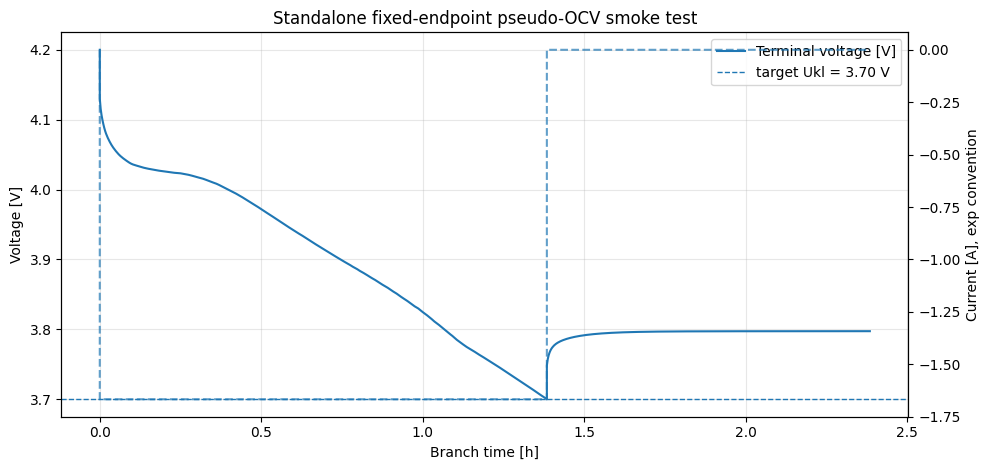

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/fixed_endpoint_pseudo_ocv_standalone_smoke.png


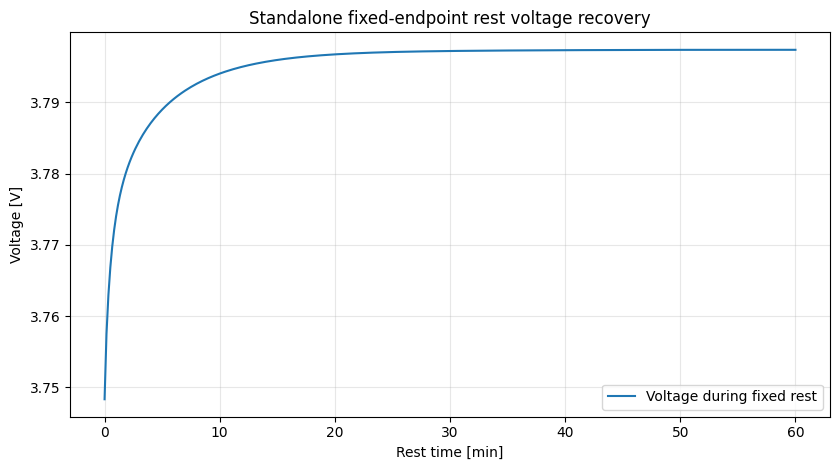

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/fixed_endpoint_pseudo_ocv_standalone_rest_recovery.png


In [8]:
# Cell 8 — Plot standalone fixed-endpoint pseudo-OCV smoke test（绘制独立固定端电压伪OCV协议曲线）

plot_df = fixed_endpoint_segment_0.copy()

fig, ax1 = plt.subplots(figsize=(10, 4.8))

ax1.plot(
    plot_df["branch_time_h"],
    plot_df["voltage_V"],
    label="Terminal voltage [V]",
)

ax1.axhline(
    FIXED_ENDPOINT_UKL_V,
    linestyle="--",
    linewidth=1,
    label=f"target Ukl = {FIXED_ENDPOINT_UKL_V:.2f} V",
)

ax1.set_xlabel("Branch time [h]")
ax1.set_ylabel("Voltage [V]")
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right")

ax2 = ax1.twinx()
ax2.step(
    plot_df["branch_time_h"],
    plot_df["current_A_exp"],
    where="post",
    linestyle="--",
    alpha=0.7,
)
ax2.set_ylabel("Current [A], exp convention")

plt.title("Standalone fixed-endpoint pseudo-OCV smoke test")

fig.tight_layout()
fig_path = FIGURES / "fixed_endpoint_pseudo_ocv_standalone_smoke.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)


# Rest-only plot
rest_df = fixed_endpoint_rest_0.copy()

fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.plot(
    rest_df["rest_time_s"] / 60,
    rest_df["voltage_V"],
    label="Voltage during fixed rest",
)

ax.set_xlabel("Rest time [min]")
ax.set_ylabel("Voltage [V]")
ax.set_title("Standalone fixed-endpoint rest voltage recovery")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "fixed_endpoint_pseudo_ocv_standalone_rest_recovery.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

## Note on preconditioning warnings

At checkpoint 0, the full-charge preconditioning charge/CV steps may be skipped because the initial state is already close to the upper-voltage boundary.

This is not treated as a failure as long as:

- the diagnostic branch solves successfully,
- the fixed-endpoint discharge reaches the target `Ukl`,
- the rest segment is complete,
- and the extracted voltage-recovery metrics are valid.

In [9]:
# Cell 9 — Degradation-state extractor（checkpoint 老化状态提取函数）

def get_solution_var_at_index(solution, candidates, index=0):
    """
    Extract one variable value at a given time index from a solution.
    Spatially resolved variables are reduced by mean.
    """
    selected = first_available_solution_variable(solution, candidates)

    if selected is None:
        return None, np.nan

    values = np.asarray(solution[selected].entries)

    if values.ndim == 1:
        return selected, float(values[index])

    return selected, float(np.mean(values[..., index]))


def extract_degradation_state(checkpoint_cycles, aging_solution, reference_solution_for_initial=None):
    """
    Extract degradation-state variables before diagnostic branches.

    checkpoint 0:
        use first point of reference_solution_for_initial.
    checkpoint > 0:
        use final point of pre-RPT aging_solution.
    """
    out = {
        "checkpoint_cycles": checkpoint_cycles,
    }

    if checkpoint_cycles == 0:
        if reference_solution_for_initial is None:
            raise ValueError("checkpoint 0 requires reference_solution_for_initial.")

        out["state_source"] = "initial_state_from_reference_solution"
        out["time_h"] = 0.0

        for short_name, candidates in degradation_variable_candidates.items():
            var_name, value = get_solution_var_at_index(
                reference_solution_for_initial,
                candidates,
                index=0,
            )
            out[short_name] = value
            out[f"{short_name}_source"] = var_name

    else:
        if aging_solution is None:
            raise ValueError("checkpoint > 0 requires aging_solution.")

        out["state_source"] = "pre_diagnostic_aging_state"
        out["time_h"] = float(aging_solution["Time [h]"].entries[-1])

        for short_name, candidates in degradation_variable_candidates.items():
            var_name, value = get_solution_var_final(aging_solution, candidates)
            out[short_name] = value
            out[f"{short_name}_source"] = var_name

    return out


print("[OK] degradation-state extractor defined")

[OK] degradation-state extractor defined


In [10]:
# Cell 10 — Run multi-checkpoint fixed-endpoint pseudo-OCV audit
# 功能：在每个 SEI aging checkpoint 上运行 full-charge preconditioning + fixed Ukl + fixed rest 诊断分支

checkpoint_solutions = {}
preconditioning_solutions = {}
preconditioning_segments = {}
fixed_endpoint_solutions = {}
fixed_endpoint_segments = {}
fixed_endpoint_rest_segments = {}

degradation_state_rows = []
fixed_endpoint_rows = []

current_aging_solution = None
current_cycles = 0

for checkpoint in CHECKPOINT_CYCLES:
    print("\n" + "=" * 90)
    print(f"[CHECKPOINT — FIXED-ENDPOINT] target cycles = {checkpoint}")

    cycles_to_run = checkpoint - current_cycles

    if cycles_to_run < 0:
        raise ValueError("CHECKPOINT_CYCLES must be non-decreasing.")

    # Continue aging only from the pre-diagnostic aging trajectory.
    if cycles_to_run > 0:
        current_aging_solution = run_aging_block(
            starting_solution=current_aging_solution,
            n_cycles=cycles_to_run,
            label=f"{current_cycles}_to_{checkpoint}_cycles_fixed_endpoint",
        )
        current_cycles = checkpoint
    else:
        print("[INFO] checkpoint 0: no aging block before diagnostic branch")

    checkpoint_solutions[checkpoint] = current_aging_solution

    # Diagnostic branch step 1: full-charge preconditioning.
    precond_solution, precond_segment = run_branch_experiment(
        starting_solution=current_aging_solution,
        experiment=build_preconditioning_experiment(),
        output_label=f"fixed_endpoint_preconditioning_checkpoint_{checkpoint}",
        initial_soc_if_none=1.0,
    )

    preconditioning_solutions[checkpoint] = precond_solution
    preconditioning_segments[checkpoint] = precond_segment

    # Extract degradation state before diagnostic branch.
    if checkpoint == 0:
        degradation_state = extract_degradation_state(
            checkpoint_cycles=checkpoint,
            aging_solution=None,
            reference_solution_for_initial=precond_solution,
        )
    else:
        degradation_state = extract_degradation_state(
            checkpoint_cycles=checkpoint,
            aging_solution=current_aging_solution,
            reference_solution_for_initial=None,
        )

    degradation_state_rows.append(degradation_state)

    # Diagnostic branch step 2: fixed endpoint discharge + fixed rest.
    fixed_solution, fixed_segment = run_branch_experiment(
        starting_solution=precond_solution,
        experiment=build_fixed_endpoint_experiment(),
        output_label=f"fixed_endpoint_pseudo_ocv_checkpoint_{checkpoint}",
        initial_soc_if_none=1.0,
    )

    fixed_endpoint_solutions[checkpoint] = fixed_solution
    fixed_endpoint_segments[checkpoint] = fixed_segment

    fixed_metrics, fixed_rest = extract_fixed_endpoint_voltage_recovery(
        segment=fixed_segment,
        checkpoint_cycles=checkpoint,
        endpoint_Ukl_V=FIXED_ENDPOINT_UKL_V,
    )

    fixed_metrics["preconditioning_strategy"] = "full_charge_C3_CV_C100_rest10min"
    fixed_metrics["fixed_endpoint_protocol"] = (
        f"{FIXED_ENDPOINT_C_RATE}_to_{FIXED_ENDPOINT_UKL_V:.2f}V_rest_{FIXED_REST_DURATION_MIN}min"
    )

    fixed_endpoint_rows.append(fixed_metrics)
    fixed_endpoint_rest_segments[checkpoint] = fixed_rest

    print(f"[OK] fixed-endpoint checkpoint {checkpoint} extracted")
    print(f"  Ukl loaded = {fixed_metrics['Ukl_loaded_V']:.6f} V")
    print(f"  Ukl error = {fixed_metrics['Ukl_error_mV']:.3f} mV")
    print(f"  Q_to_Ukl = {fixed_metrics['Q_to_Ukl_Ah']:.6f} Ah")
    print(f"  nominal SOC at endpoint = {fixed_metrics['nominal_soc_percent_at_endpoint']:.3f} %")
    print(f"  U_after_interrupt = {fixed_metrics['U_after_interrupt_V']:.6f} V")
    print(f"  U00_after_fixed_rest = {fixed_metrics['U00_after_fixed_rest_V']:.6f} V")
    print(f"  recovery amplitude = {fixed_metrics['recovery_amplitude_V']*1000:.3f} mV")
    print(f"  rest duration = {fixed_metrics['rest_duration_min']:.3f} min")

fixed_endpoint_degradation_state_table = pd.DataFrame(degradation_state_rows)
fixed_endpoint_pseudo_ocv_table = pd.DataFrame(fixed_endpoint_rows)

out_csv = DATA / "fixed_endpoint_pseudo_ocv_degradation_state_table.csv"
fixed_endpoint_degradation_state_table.to_csv(out_csv, index=False)
print("\n[OK] saved:", out_csv)

out_csv = DATA / "fixed_endpoint_pseudo_ocv_metric_table.csv"
fixed_endpoint_pseudo_ocv_table.to_csv(out_csv, index=False)
print("[OK] saved:", out_csv)

display(fixed_endpoint_degradation_state_table)
display(fixed_endpoint_pseudo_ocv_table)


[CHECKPOINT — FIXED-ENDPOINT] target cycles = 0
[INFO] checkpoint 0: no aging block before diagnostic branch


2026-05-12 19:57:26.731 - [WARNING] simulation.solve(1197): Step 'Charge at C/3 until 4.2 V' is infeasible at initial conditions, but skip_ok is True. Skipping step.
2026-05-12 19:57:26.776 - [WARNING] simulation.solve(1197): Step 'Hold at 4.2 V until C/100' is infeasible at initial conditions, but skip_ok is True. Skipping step.


[OK] branch solved: fixed_endpoint_preconditioning_checkpoint_0
  segment duration [h]: 0.16666666666666666
[OK] branch solved: fixed_endpoint_pseudo_ocv_checkpoint_0
  segment duration [h]: 2.384251991418423
[OK] fixed-endpoint checkpoint 0 extracted
  Ukl loaded = 3.700000 V
  Ukl error = 0.000 mV
  Q_to_Ukl = 2.307087 Ah
  nominal SOC at endpoint = 53.858 %
  U_after_interrupt = 3.748310 V
  U00_after_fixed_rest = 3.797388 V
  recovery amplitude = 49.079 mV
  rest duration = 60.000 min

[CHECKPOINT — FIXED-ENDPOINT] target cycles = 3


2026-05-12 19:57:28.172 - [WARNING] simulation.solve(1197): Step 'Charge at C/3 until 4.2 V' is infeasible at initial conditions, but skip_ok is True. Skipping step.


[OK] aging block solved: 0_to_3_cycles_fixed_endpoint
  cycles in block: 3
  final time [h]: 21.358301790137954
[OK] branch solved: fixed_endpoint_preconditioning_checkpoint_3
  segment duration [h]: 0.2092874119566477
[OK] branch solved: fixed_endpoint_pseudo_ocv_checkpoint_3
  segment duration [h]: 2.3789254359066643
[OK] fixed-endpoint checkpoint 3 extracted
  Ukl loaded = 3.700000 V
  Ukl error = 0.000 mV
  Q_to_Ukl = 2.298209 Ah
  nominal SOC at endpoint = 54.036 %
  U_after_interrupt = 3.748373 V
  U00_after_fixed_rest = 3.797401 V
  recovery amplitude = 49.028 mV
  rest duration = 60.000 min

[CHECKPOINT — FIXED-ENDPOINT] target cycles = 10


...

[OK] aging block solved: 3_to_10_cycles_fixed_endpoint
  cycles in block: 7
  final time [h]: 71.16724893166092
[OK] branch solved: fixed_endpoint_preconditioning_checkpoint_10
  segment duration [h]: 0.2097900870091932
[OK] branch solved: fixed_endpoint_pseudo_ocv_checkpoint_10
  segment duration [h]: 2.378416262473458
[OK] fixed-endpoint checkpoint 10 extracted
  Ukl loaded = 3.700000 V
  Ukl error = -0.000 mV
  Q_to_Ukl = 2.297360 Ah
  nominal SOC at endpoint = 54.053 %
  U_after_interrupt = 3.748539 V
  U00_after_fixed_rest = 3.797581 V
  recovery amplitude = 49.042 mV
  rest duration = 60.000 min

[CHECKPOINT — FIXED-ENDPOINT] target cycles = 20
[OK] aging block solved: 10_to_20_cycles_fixed_endpoint
  cycles in block: 10
  final time [h]: 142.30391843845703


2026-05-12 19:57:33.101 - [WARNING] simulation.solve(1197): Step 'Charge at C/3 until 4.2 V' is infeasible at initial conditions, but skip_ok is True. Skipping step.


[OK] branch solved: fixed_endpoint_preconditioning_checkpoint_20
  segment duration [h]: 0.21018006781693355
[OK] branch solved: fixed_endpoint_pseudo_ocv_checkpoint_20
  segment duration [h]: 2.377843747389755
[OK] fixed-endpoint checkpoint 20 extracted
  Ukl loaded = 3.700000 V
  Ukl error = -0.000 mV
  Q_to_Ukl = 2.296406 Ah
  nominal SOC at endpoint = 54.072 %
  U_after_interrupt = 3.748727 V
  U00_after_fixed_rest = 3.797795 V
  recovery amplitude = 49.069 mV
  rest duration = 60.000 min

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/fixed_endpoint_pseudo_ocv_degradation_state_table.csv
[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/fixed_endpoint_pseudo_ocv_metric_table.csv


,checkpoint_cycles,state_source,time_h,sei_thickness_m,sei_thickness_m_source,loss_lithium_inventory_pct,loss_lithium_inventory_pct_source,total_lithium_lost_mol,total_lithium_lost_mol_source,capacity_lost_side_reactions_Ah,capacity_lost_side_reactions_Ah_source
0,0,initial_state_from_reference_solution,0.000000,5.000000e-09,X-averaged negative SEI thickness [m],1.421085e-13,Loss of lithium inventory [%],-5.551115e-17,Total lithium lost [mol],0.000000,Total capacity lost to side reactions [A.h]
1,3,pre_diagnostic_aging_state,21.358302,5.891818e-09,X-averaged negative SEI thickness [m],1.100811e-02,Loss of lithium inventory [%],3.125929e-05,Total lithium lost [mol],0.000838,Total capacity lost to side reactions [A.h]
2,10,pre_diagnostic_aging_state,71.167249,7.574040e-09,X-averaged negative SEI thickness [m],3.177252e-02,Loss of lithium inventory [%],9.022319e-05,Total lithium lost [mol],0.002418,Total capacity lost to side reactions [A.h]
3,20,pre_diagnostic_aging_state,142.303918,9.471973e-09,X-averaged negative SEI thickness [m],5.519954e-02,Loss of lithium inventory [%],1.567480e-04,Total lithium lost [mol],0.004201,Total capacity lost to side reactions [A.h]


,checkpoint_cycles,endpoint_target_Ukl_V,Ukl_loaded_V,Ukl_error_mV,t_to_Ukl_s,t_to_Ukl_h,Q_to_Ukl_Ah,throughput_to_Ukl_Ah,nominal_capacity_Ah,nominal_soc_at_endpoint,nominal_soc_percent_at_endpoint,I_endpoint_A_pybamm,U_after_interrupt_V,U00_after_fixed_rest_V,rest_duration_s,rest_duration_min,recovery_amplitude_V,recovery_from_loaded_endpoint_V,preconditioning_strategy,fixed_endpoint_protocol
0,0,3.7,3.7,0.000000e+00,4983.307169,1.384252,2.307087,2.307087,5.0,0.538583,53.858267,1.666667,3.748310,3.797388,3600.0,60.0,0.049079,0.097388,full_charge_C3_CV_C100_rest10min,C/3_to_3.70V_rest_60min
1,3,3.7,3.7,0.000000e+00,4964.131569,1.378925,2.298209,2.298209,5.0,0.540358,54.035819,1.666667,3.748373,3.797401,3600.0,60.0,0.049028,0.097401,full_charge_C3_CV_C100_rest10min,C/3_to_3.70V_rest_60min
2,10,3.7,3.7,-8.881784e-13,4962.298545,1.378416,2.297360,2.297360,5.0,0.540528,54.052791,1.666667,3.748539,3.797581,3600.0,60.0,0.049042,0.097581,full_charge_C3_CV_C100_rest10min,C/3_to_3.70V_rest_60min
3,20,3.7,3.7,-5.080381e-10,4960.237491,1.377844,2.296406,2.296406,5.0,0.540719,54.071875,1.666667,3.748727,3.797795,3600.0,60.0,0.049069,0.097795,full_charge_C3_CV_C100_rest10min,C/3_to_3.70V_rest_60min


In [11]:
# Cell 11 — Fixed-endpoint protocol quality audit（固定端电压协议质量审计）

quality_rows = []

for _, row in fixed_endpoint_pseudo_ocv_table.iterrows():
    quality_rows.append(
        {
            "checkpoint_cycles": row["checkpoint_cycles"],
            "Ukl_error_mV": row["Ukl_error_mV"],
            "abs_Ukl_error_mV": abs(row["Ukl_error_mV"]),
            "rest_duration_min": row["rest_duration_min"],
            "rest_duration_error_min": row["rest_duration_min"] - FIXED_REST_DURATION_MIN,
            "Q_to_Ukl_Ah": row["Q_to_Ukl_Ah"],
            "nominal_soc_percent_at_endpoint": row["nominal_soc_percent_at_endpoint"],
            "quality_flag": (
                "pass"
                if abs(row["Ukl_error_mV"]) <= 2.0
                and abs(row["rest_duration_min"] - FIXED_REST_DURATION_MIN) <= 0.1
                else "check"
            ),
        }
    )

fixed_endpoint_quality_audit = pd.DataFrame(quality_rows)

out_csv = DATA / "fixed_endpoint_pseudo_ocv_quality_audit.csv"
fixed_endpoint_quality_audit.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(fixed_endpoint_quality_audit)

print("Max abs Ukl error [mV]:", fixed_endpoint_quality_audit["abs_Ukl_error_mV"].max())
print("Max abs rest duration error [min]:", fixed_endpoint_quality_audit["rest_duration_error_min"].abs().max())

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/fixed_endpoint_pseudo_ocv_quality_audit.csv


,checkpoint_cycles,Ukl_error_mV,abs_Ukl_error_mV,rest_duration_min,rest_duration_error_min,Q_to_Ukl_Ah,nominal_soc_percent_at_endpoint,quality_flag
0,0,0.000000e+00,0.000000e+00,60.0,-1.421085e-14,2.307087,53.858267,pass
1,3,0.000000e+00,0.000000e+00,60.0,-2.415845e-13,2.298209,54.035819,pass
2,10,-8.881784e-13,8.881784e-13,60.0,-4.831691e-13,2.297360,54.052791,pass
3,20,-5.080381e-10,5.080381e-10,60.0,-9.734435e-13,2.296406,54.071875,pass


Max abs Ukl error [mV]: 5.080380560684716e-10
Max abs rest duration error [min]: 9.734435479913373e-13


In [12]:
# Cell 12 — Build fixed-endpoint pseudo-OCV drift table（构建相对 0-cycle 的固定端电压漂移表）

ref = fixed_endpoint_pseudo_ocv_table[
    fixed_endpoint_pseudo_ocv_table["checkpoint_cycles"] == 0
].iloc[0]

deg_ref = fixed_endpoint_degradation_state_table[
    fixed_endpoint_degradation_state_table["checkpoint_cycles"] == 0
].iloc[0]

metrics = [
    "t_to_Ukl_s",
    "Q_to_Ukl_Ah",
    "throughput_to_Ukl_Ah",
    "nominal_soc_percent_at_endpoint",
    "U_after_interrupt_V",
    "U00_after_fixed_rest_V",
    "recovery_amplitude_V",
    "recovery_from_loaded_endpoint_V",
]

deg_metrics = [
    "sei_thickness_m",
    "loss_lithium_inventory_pct",
    "total_lithium_lost_mol",
    "capacity_lost_side_reactions_Ah",
]

drift_rows = []

for _, row in fixed_endpoint_pseudo_ocv_table.sort_values("checkpoint_cycles").iterrows():
    ckpt = row["checkpoint_cycles"]

    deg_row = fixed_endpoint_degradation_state_table[
        fixed_endpoint_degradation_state_table["checkpoint_cycles"] == ckpt
    ].iloc[0]

    out = {
        "checkpoint_cycles": ckpt,
        "endpoint_target_Ukl_V": FIXED_ENDPOINT_UKL_V,
        "fixed_rest_duration_min": FIXED_REST_DURATION_MIN,
    }

    for m in deg_metrics:
        val = deg_row[m]
        base = deg_ref[m]
        out[m] = val
        out[f"{m}_delta_vs_0cycle"] = val - base
        out[f"{m}_rel_pct_vs_0cycle"] = (
            100 * (val - base) / base if abs(base) > 1e-30 else np.nan
        )

    for m in metrics:
        val = row[m]
        base = ref[m]
        out[m] = val
        out[f"{m}_delta_vs_0cycle"] = val - base
        out[f"{m}_rel_pct_vs_0cycle"] = (
            100 * (val - base) / base if abs(base) > 1e-30 else np.nan
        )

    drift_rows.append(out)

fixed_endpoint_drift_table = pd.DataFrame(drift_rows)

out_csv = DATA / "fixed_endpoint_pseudo_ocv_drift_table.csv"
fixed_endpoint_drift_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(fixed_endpoint_drift_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/fixed_endpoint_pseudo_ocv_drift_table.csv


,checkpoint_cycles,endpoint_target_Ukl_V,fixed_rest_duration_min,sei_thickness_m,sei_thickness_m_delta_vs_0cycle,sei_thickness_m_rel_pct_vs_0cycle,loss_lithium_inventory_pct,loss_lithium_inventory_pct_delta_vs_0cycle,loss_lithium_inventory_pct_rel_pct_vs_0cycle,total_lithium_lost_mol,...,U_after_interrupt_V_rel_pct_vs_0cycle,U00_after_fixed_rest_V,U00_after_fixed_rest_V_delta_vs_0cycle,U00_after_fixed_rest_V_rel_pct_vs_0cycle,recovery_amplitude_V,recovery_amplitude_V_delta_vs_0cycle,recovery_amplitude_V_rel_pct_vs_0cycle,recovery_from_loaded_endpoint_V,recovery_from_loaded_endpoint_V_delta_vs_0cycle,recovery_from_loaded_endpoint_V_rel_pct_vs_0cycle
0,0,3.7,60,5.000000e-09,0.000000e+00,0.000000,1.421085e-13,0.000000,0.000000e+00,-5.551115e-17,...,0.000000,3.797388,0.000000,0.000000,0.049079,0.000000,0.000000,0.097388,0.000000,0.000000
1,3,3.7,60,5.891818e-09,8.918182e-10,17.836365,1.100811e-02,0.011008,7.746267e+12,3.125929e-05,...,0.001677,3.797401,0.000013,0.000334,0.049028,-0.000050,-0.102207,0.097401,0.000013,0.013020
2,10,3.7,60,7.574040e-09,2.574040e-09,51.480806,3.177252e-02,0.031773,2.235792e+13,9.022319e-05,...,0.006100,3.797581,0.000192,0.005064,0.049042,-0.000036,-0.074058,0.097581,0.000192,0.197474
3,20,3.7,60,9.471973e-09,4.471973e-09,89.439453,5.519954e-02,0.055200,3.884322e+13,1.567480e-04,...,0.011118,3.797795,0.000407,0.010720,0.049069,-0.000010,-0.019701,0.097795,0.000407,0.418003


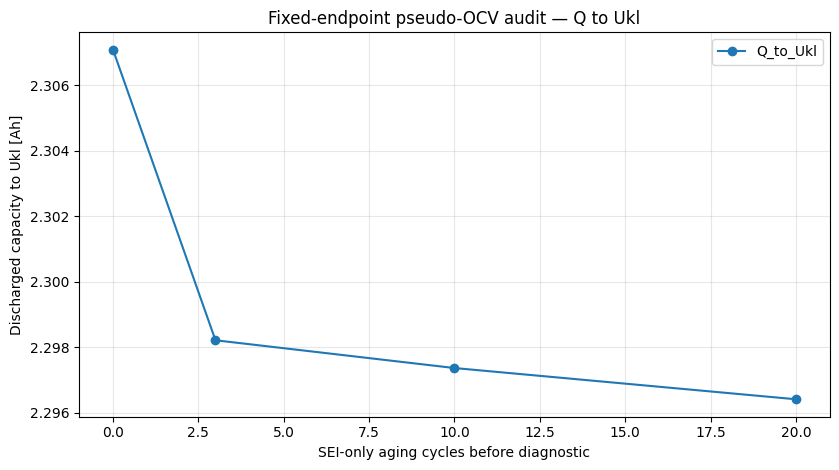

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/fixed_endpoint_pseudo_ocv_Q_to_Ukl_drift.png


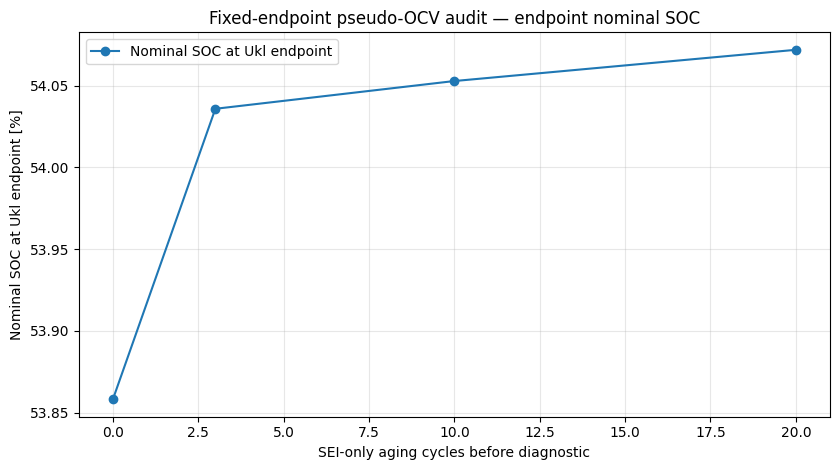

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/fixed_endpoint_pseudo_ocv_endpoint_soc_drift.png


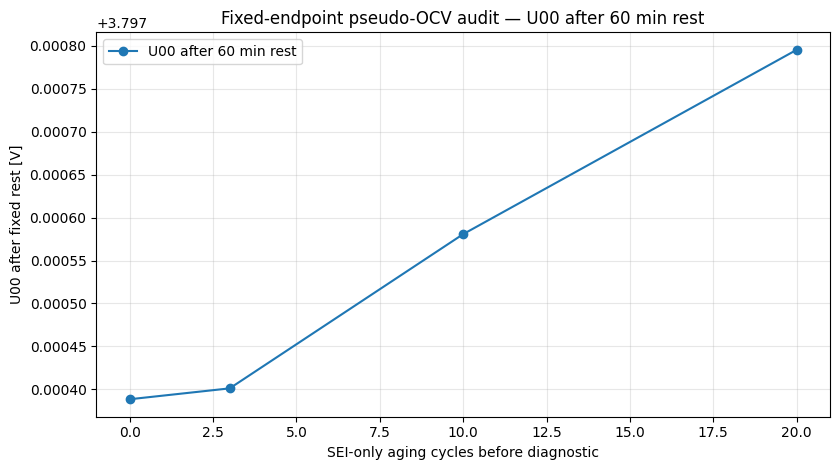

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/fixed_endpoint_pseudo_ocv_U00_after_rest_drift.png


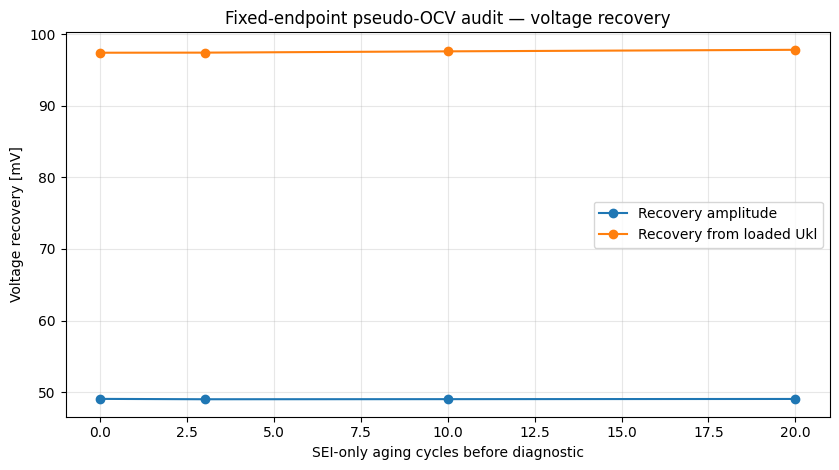

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/fixed_endpoint_pseudo_ocv_recovery_features.png


In [13]:
# Cell 13 — Plot fixed-endpoint pseudo-OCV trends（绘制固定端电压伪OCV趋势）

plot_df = fixed_endpoint_drift_table.sort_values("checkpoint_cycles").copy()

# Q_to_Ukl drift
fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.plot(
    plot_df["checkpoint_cycles"],
    plot_df["Q_to_Ukl_Ah"],
    marker="o",
    label="Q_to_Ukl",
)

ax.set_xlabel("SEI-only aging cycles before diagnostic")
ax.set_ylabel("Discharged capacity to Ukl [Ah]")
ax.set_title("Fixed-endpoint pseudo-OCV audit — Q to Ukl")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "fixed_endpoint_pseudo_ocv_Q_to_Ukl_drift.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)


# Nominal SOC at endpoint
fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.plot(
    plot_df["checkpoint_cycles"],
    plot_df["nominal_soc_percent_at_endpoint"],
    marker="o",
    label="Nominal SOC at Ukl endpoint",
)

ax.set_xlabel("SEI-only aging cycles before diagnostic")
ax.set_ylabel("Nominal SOC at Ukl endpoint [%]")
ax.set_title("Fixed-endpoint pseudo-OCV audit — endpoint nominal SOC")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "fixed_endpoint_pseudo_ocv_endpoint_soc_drift.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)


# U00 after fixed rest
fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.plot(
    plot_df["checkpoint_cycles"],
    plot_df["U00_after_fixed_rest_V"],
    marker="o",
    label="U00 after 60 min rest",
)

ax.set_xlabel("SEI-only aging cycles before diagnostic")
ax.set_ylabel("U00 after fixed rest [V]")
ax.set_title("Fixed-endpoint pseudo-OCV audit — U00 after 60 min rest")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "fixed_endpoint_pseudo_ocv_U00_after_rest_drift.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)


# Recovery features
fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.plot(
    plot_df["checkpoint_cycles"],
    plot_df["recovery_amplitude_V"] * 1000,
    marker="o",
    label="Recovery amplitude",
)

ax.plot(
    plot_df["checkpoint_cycles"],
    plot_df["recovery_from_loaded_endpoint_V"] * 1000,
    marker="o",
    label="Recovery from loaded Ukl",
)

ax.set_xlabel("SEI-only aging cycles before diagnostic")
ax.set_ylabel("Voltage recovery [mV]")
ax.set_title("Fixed-endpoint pseudo-OCV audit — voltage recovery")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "fixed_endpoint_pseudo_ocv_recovery_features.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

In [14]:
# Cell 14 — Fixed-endpoint monotonicity audit（固定端电压指标单调性审计）

def monotonic_increasing(values, tol=1e-12):
    values = np.asarray(values, dtype=float)
    return bool(np.all(np.diff(values) >= -tol))


def monotonic_decreasing(values, tol=1e-12):
    values = np.asarray(values, dtype=float)
    return bool(np.all(np.diff(values) <= tol))


audit_specs = [
    {
        "metric": "Q_to_Ukl_Ah",
        "expected_direction": "decrease",
        "unit": "Ah",
    },
    {
        "metric": "nominal_soc_percent_at_endpoint",
        "expected_direction": "increase",
        "unit": "%",
    },
    {
        "metric": "U_after_interrupt_V",
        "expected_direction": "increase",
        "unit": "V",
    },
    {
        "metric": "U00_after_fixed_rest_V",
        "expected_direction": "increase",
        "unit": "V",
    },
    {
        "metric": "recovery_amplitude_V",
        "expected_direction": "small_or_neutral",
        "unit": "V",
    },
    {
        "metric": "recovery_from_loaded_endpoint_V",
        "expected_direction": "increase",
        "unit": "V",
    },
]

audit_rows = []

for spec in audit_specs:
    metric = spec["metric"]
    values = plot_df[metric].values

    if spec["expected_direction"] == "increase":
        monotonic = monotonic_increasing(values)
    elif spec["expected_direction"] == "decrease":
        monotonic = monotonic_decreasing(values)
    else:
        monotonic = None

    audit_rows.append(
        {
            "metric": metric,
            "unit": spec["unit"],
            "expected_direction": spec["expected_direction"],
            "start_value": float(values[0]),
            "final_value": float(values[-1]),
            "final_delta": float(values[-1] - values[0]),
            "monotonic_result": monotonic,
            "values_by_checkpoint": values.tolist(),
        }
    )

fixed_endpoint_monotonicity_audit = pd.DataFrame(audit_rows)

out_csv = DATA / "fixed_endpoint_pseudo_ocv_monotonicity_audit.csv"
fixed_endpoint_monotonicity_audit.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(fixed_endpoint_monotonicity_audit)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/fixed_endpoint_pseudo_ocv_monotonicity_audit.csv


,metric,unit,expected_direction,start_value,final_value,final_delta,monotonic_result,values_by_checkpoint
0,Q_to_Ukl_Ah,Ah,decrease,2.307087,2.296406,-0.010680,True,"[2.307086652364036, 2.298209059844268, 2.29736..."
1,nominal_soc_percent_at_endpoint,%,increase,53.858267,54.071875,0.213608,True,"[53.85826695271928, 54.03581880311463, 54.0527..."
2,U_after_interrupt_V,V,increase,3.748310,3.748727,0.000417,True,"[3.7483098500676206, 3.748372691989185, 3.7485..."
3,U00_after_fixed_rest_V,V,increase,3.797388,3.797795,0.000407,True,"[3.7973883663646815, 3.7974010466851524, 3.797..."
4,recovery_amplitude_V,V,small_or_neutral,0.049079,0.049069,-0.000010,None,"[0.04907851629706084, 0.04902835469596756, 0.0..."
5,recovery_from_loaded_endpoint_V,V,increase,0.097388,0.097795,0.000407,True,"[0.09738836636468129, 0.09740104668515226, 0.0..."


In [15]:
# Cell 15 — Fixed-endpoint pseudo-OCV classification table（固定端电压伪OCV指纹分类表）

final_row = fixed_endpoint_drift_table.sort_values("checkpoint_cycles").iloc[-1]

classification_rows = [
    {
        "metric_layer": "protocol_quality",
        "evidence": (
            f"Max abs Ukl error = {fixed_endpoint_quality_audit['abs_Ukl_error_mV'].max():.3e} mV; "
            f"max rest-duration error = {fixed_endpoint_quality_audit['rest_duration_error_min'].abs().max():.3e} min"
        ),
        "strength": "strong",
        "classification": "fixed-endpoint protocol is technically clean",
    },
    {
        "metric_layer": "Q_to_Ukl",
        "evidence": (
            f"Q_to_Ukl decreased by {final_row['Q_to_Ukl_Ah_delta_vs_0cycle']:.6f} Ah "
            f"from 0-cycle to 20-cycle checkpoint"
        ),
        "strength": "clear",
        "classification": "same-Ukl endpoint is reached with less discharged capacity after SEI aging",
    },
    {
        "metric_layer": "endpoint_nominal_SOC",
        "evidence": (
            f"nominal SOC at endpoint shifted by "
            f"{final_row['nominal_soc_percent_at_endpoint_delta_vs_0cycle']:.4f} percentage points"
        ),
        "strength": "clear but small",
        "classification": "same loaded Ukl does not imply identical SOC/state",
    },
    {
        "metric_layer": "U00_after_fixed_rest",
        "evidence": (
            f"U00 after 60 min rest shifted by "
            f"{final_row['U00_after_fixed_rest_V_delta_vs_0cycle']*1000:.4f} mV"
        ),
        "strength": "weak",
        "classification": "finite-rest voltage recovery shows weak positive drift",
    },
    {
        "metric_layer": "recovery_amplitude",
        "evidence": (
            f"recovery amplitude shifted by "
            f"{final_row['recovery_amplitude_V_delta_vs_0cycle']*1000:.4f} mV"
        ),
        "strength": "very weak / neutral",
        "classification": "recovery amplitude is not a dominant SEI-only fingerprint in this protocol",
    },
    {
        "metric_layer": "overall",
        "evidence": (
            "Q_to_Ukl decreases, endpoint nominal SOC increases slightly, "
            "U00_after_fixed_rest increases weakly, recovery amplitude remains nearly unchanged"
        ),
        "strength": "feasibility-level diagnostic layer",
        "classification": (
            "fixed-endpoint pseudo-OCV features are extractable and consistent with capacity/LLI shift, "
            "but they are secondary compared with capacity RPT and degradation-state metrics"
        ),
    },
]

fixed_endpoint_classification_table = pd.DataFrame(classification_rows)

out_csv = DATA / "fixed_endpoint_pseudo_ocv_classification_table.csv"
fixed_endpoint_classification_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(fixed_endpoint_classification_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/fixed_endpoint_pseudo_ocv_classification_table.csv


,metric_layer,evidence,strength,classification
0,protocol_quality,Max abs Ukl error = 5.080e-10 mV; max rest-dur...,strong,fixed-endpoint protocol is technically clean
1,Q_to_Ukl,Q_to_Ukl decreased by -0.010680 Ah from 0-cycl...,clear,same-Ukl endpoint is reached with less dischar...
2,endpoint_nominal_SOC,nominal SOC at endpoint shifted by 0.2136 perc...,clear but small,same loaded Ukl does not imply identical SOC/s...
3,U00_after_fixed_rest,U00 after 60 min rest shifted by 0.4071 mV,weak,finite-rest voltage recovery shows weak positi...
4,recovery_amplitude,recovery amplitude shifted by -0.0097 mV,very weak / neutral,recovery amplitude is not a dominant SEI-only ...
5,overall,"Q_to_Ukl decreases, endpoint nominal SOC incre...",feasibility-level diagnostic layer,fixed-endpoint pseudo-OCV features are extract...
